In [1]:
import os
import torch
import numpy as np
from extract import extract_graph, extract_die_area, load_file_content
import scipy.sparse as sp 
from helper import normalize_features, build_X_hop_mask , get_compressed_graph , relative_masking

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = "dataset_with_def/placement_files/"

# --- CONTROL KNOB ---
max_designs_to_load = 2 # Set this to however many designs you want to test right now
# --------------------

training_dataset = []
global_max_k = 0
global_max_cell_types = 0
loaded_count = 0

print(f"Starting Multi-Graph Pipeline (Targeting {max_designs_to_load} designs)...\n" + "="*50)

# Iterate over every folder in your base directory
for run_folder in os.listdir(base_dir):
    # Stop if we hit our requested limit
    if loaded_count >= max_designs_to_load:
        print(f"\nReached target limit of {max_designs_to_load} designs. Stopping extraction.")
        break

    folder_path = os.path.join(base_dir, run_folder)
    
    if not os.path.isdir(folder_path):
        continue
        
    design_name = run_folder.split("_")[0]
    print(f"\nProcessing Design: {design_name} (Run: {run_folder})")
    
    # 1. Build Paths
    def_path = os.path.join(folder_path, f"{design_name}.def")
    saif_path = os.path.join(folder_path, f"{design_name}.saif")
    timing_path = os.path.join(folder_path, "timing_paths.csv")
    
    if not (os.path.exists(def_path) and os.path.exists(saif_path) and os.path.exists(timing_path)):
        print(f"  -> WARNING: Missing files for {design_name}. Skipping.")
        continue

    # 2. Extract Raw Graph Data
    graph = extract_graph(def_path, saif_path, timing_path, clock_port="clk")
    def_text = load_file_content(def_path)
    die_x_min, die_y_min, die_x_max, die_y_max = extract_die_area(def_text)
    
    num_nodes = len(graph['nodes'])
    print(f"  -> Nodes: {num_nodes} | Undirected Edges: {graph['undirected_edges'].shape[1]}")
    
    # 3. Process REAL Features
    X_float, X_cell_ids, norm_stats = normalize_features(
        graph['nodes'], 
        die_x_min, die_y_min, die_x_max, die_y_max
    )

    # 4. Build the 3-Hop Mask (The P matrix structure)
    rows, cols = build_X_hop_mask(num_nodes, graph['undirected_edges'], hop_mask_len=3)
    p_indices = torch.tensor(np.array([rows, cols]), dtype=torch.long)

    # 5. Build the Skip Edges (Timing paths) Sparse Matrix
    if len(graph['skip_edges']) > 0:
        skip_rows = torch.tensor(graph['skip_edges'][:, 0], dtype=torch.long)
        skip_cols = torch.tensor(graph['skip_edges'][:, 1], dtype=torch.long)
    else:
        skip_rows, skip_cols = torch.tensor([], dtype=torch.long), torch.tensor([], dtype=torch.long)
        
    skip_indices = torch.stack([skip_rows, skip_cols])
    skip_vals = torch.ones(skip_rows.size(0))
    A_skip_csr = torch.sparse_coo_tensor(skip_indices, skip_vals, (num_nodes, num_nodes)).coalesce().to_sparse_csr()

    # 6. Calculate K for this specific design
    n_ff = (X_float[:, 10] == 1.0).sum().item()
    current_k = max(1, int(n_ff // 2))
    
    # Update Global Maximums
    global_max_k = max(global_max_k, current_k)
    global_max_cell_types = max(global_max_cell_types, int(X_cell_ids.max().item() + 1))

    # ==========================================
    # 5.5 Build the 1-Hop Wire Edges (FIXED)
    # ==========================================
    if graph['undirected_edges'].shape[0] > 0:
        # Indices are currently [Edges, 2]. We need to split the COLUMNS.
        wire_rows = torch.tensor(graph['undirected_edges'][:, 0], dtype=torch.long)
        wire_cols = torch.tensor(graph['undirected_edges'][:, 1], dtype=torch.long)
    else:
        wire_rows, wire_cols = torch.tensor([], dtype=torch.long), torch.tensor([], dtype=torch.long)
        
    wire_indices = torch.stack([wire_rows, wire_cols])
    wire_vals = torch.ones(wire_rows.size(0))
    
    # This NxN sparse matrix will now correctly have ~36,000 entries
    A_wire_csr = torch.sparse_coo_tensor(
        wire_indices, 
        wire_vals, 
        (num_nodes, num_nodes)
    ).coalesce().to_sparse_csr()


    # 7. Package and Store in memory
    graph_data = {
        'name': design_name,
        'num_nodes': num_nodes,
        'X': X_float.to(device),
        'X_cell_ids': X_cell_ids.to(device),
        'p_indices': p_indices.to(device),
        'A_skip_csr': A_skip_csr.to(device),
        'current_k': current_k, 
        'A_wire_csr': A_wire_csr.to(device)
    }
    training_dataset.append(graph_data)
    loaded_count += 1
    print(f"  -> Successfully packaged! Required K: {current_k}")

print("\n" + "="*50)
print(f"Total Designs Loaded: {len(training_dataset)}")
print(f"GLOBAL MAX CELL TYPES: {global_max_cell_types}")

Starting Multi-Graph Pipeline (Targeting 2 designs)...

Processing Design: picorv32 (Run: picorv32_run_20260306_135024)
Building cell vocabulary from sky130_fd_sc_hd_tt_025C_1v80.lib...
Vocabulary: 428 unique cells
Flip-flops: 1597
Unique pairs: 3158, dropped: 0
Skip edges shape: (3158, 2)
Nodes: 6801
Directed edges: 18072
Undirected edges: 36144
Flip-flops: 1597
Fan-in  — max: 6, avg: 2.7
Fan-out — max: 139, avg: 2.7
  -> Nodes: 6801 | Undirected Edges: 2
  -> Hop 2 expansion complete.
  -> Hop 3 expansion complete.
Mask created! 1,720,772 total connections allowed.


/tmp/ipykernel_15319/2249487215.py:73: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  A_skip_csr = torch.sparse_coo_tensor(skip_indices, skip_vals, (num_nodes, num_nodes)).coalesce().to_sparse_csr()


  -> Successfully packaged! Required K: 798

Processing Design: aes (Run: aes_run_20260307_110223)
Flip-flops: 2994
Unique pairs: 5596, dropped: 0
Skip edges shape: (5596, 2)
Nodes: 15962
Directed edges: 45797
Undirected edges: 91594
Flip-flops: 2994
Fan-in  — max: 6, avg: 2.9
Fan-out — max: 172, avg: 2.9
  -> Nodes: 15962 | Undirected Edges: 2
  -> Hop 2 expansion complete.
  -> Hop 3 expansion complete.
Mask created! 7,286,648 total connections allowed.
  -> Successfully packaged! Required K: 1497

Reached target limit of 2 designs. Stopping extraction.

Total Designs Loaded: 2
GLOBAL MAX CELL TYPES: 425


In [2]:
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

class FirstTerm(nn.Module):
    def __init__(self, num_cell_types, num_of_clusters , embedding_dim=8):
        super().__init__()
        self.cell_embedding = nn.Embedding(num_cell_types, embedding_dim)
        # Initialize 10.9M weights (The Dials)
        feature_dim = 18 + embedding_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(feature_dim*2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        nn.init.normal_(self.edge_mlp[2].weight, mean=0.0, std=0.001)
        nn.init.constant_(self.edge_mlp[2].bias, 0.01)


        # 3. THE CLUSTER HEAD (The C-Matrix Generator)
        # This replaces the N x K parameter bottleneck.
        self.cluster_head = nn.Sequential(
            nn.Linear(18 + embedding_dim, 64), 
            nn.ReLU(),
            nn.Linear(64, num_of_clusters)      # Output is K clusters
        )



    def forward(self, X, X_cell_ids, num_nodes, p_indices, A_skip_csr, current_k, tau=1.0):
        
        X_cell_ids = X_cell_ids.squeeze()
        cell_features = self.cell_embedding(X_cell_ids)  # Shape: [num_nodes, embedding_dim]
        X_combined = torch.cat([X, cell_features], dim=1)  # Shape: [num_nodes, 18 + embedding_dim]

        src_features = X_combined[p_indices[0]]  # Shape: [num_edges, feature_dim]
        dst_features = X_combined[p_indices[1]]  # Shape: [num_edges, feature_dim]
        edge_inputs = torch.cat([src_features, dst_features], dim=1)  # Shape: [num_edges, feature_dim*2]

        dynamic_p_weights = self.edge_mlp(edge_inputs).squeeze(-1)
        safe_weights = F.softplus(dynamic_p_weights) 


        # Enforce P >= 0 and build sparse matrix
        P = torch.sparse_coo_tensor(p_indices, safe_weights, 
                                    (num_nodes, num_nodes)).coalesce()
        
        # Reconstruction: XP
        X_hat = torch.sparse.mm(P, X)
        
        # Loss: ||X - XP||
        error = X - X_hat
        loss1 = torch.mean(error**2)   

        # Pass all node features through the head
        logits = self.cluster_head(X_combined) # Shape: [n, k]

        logits = logits[:, :current_k]
        
        #TERM2
        #C matrix with probability distribution across clusters for each node
        C = F.gumbel_softmax(logits, tau=tau, hard=False) # Shape: [n, k]
        # C = F.softmax(logits, dim=-1)  # Ensure positivity for SDDMM

        p_vals = P.values()
        
        # 1. Sum across rows (dim=1) to get the total weight leaving each node
        row_sums = torch.sparse.sum(P, dim=1).to_dense()
        
        # 2. Expand row_sums to match the non-zero values 
        # P.indices()[0] contains the row index for every specific edge
        p_vals_norm = p_vals / (row_sums[P.indices()[0]] + 1e-8)
        
        # Rebuild using the exact same sorted indices
        P_norm = torch.sparse_coo_tensor(P.indices(), p_vals_norm, 
                                         (num_nodes, num_nodes)).coalesce()
        
        # 2. Convert to CSR format (Required for the CUDA SDDMM engine)
        P_csr = P_norm.to_sparse_csr()
        
        # 3. SDDMM Magic! 
        # beta=1.0, alpha=-1.0 calculates exactly: (1.0 * P_csr) - (1.0 * C @ C^T)
        # It ONLY calculates this at the 10.9M non-zero locations!
        diff_csr = torch.sparse.sampled_addmm(P_csr, C, C.t(), beta=1.0, alpha=-1.0)
        
        # 4. Square the differences and sum them
        loss2 = torch.sum(diff_csr.values() ** 2)


        #TERM3
        M = torch.matmul(C.t(), torch.sparse.mm(A_skip_csr, C))  # [k, n] @ [n, n] @ [n, k] -> [k, k]
        # 2. Normalize M into a probability distribution (M_tilde)
        M = torch.clamp(M, min=0)
        M_tilde = M / (M.sum() + 1e-8)
        loss3 = -torch.sum(M_tilde * torch.log(M_tilde + 1e-8))

        # 3. Calculate Shannon Entropy: -sum(p * log(p))
        # We only calculate for non-zero entries to avoid log(0)
        # loss3 = torch.sum(M_tilde * torch.log(M_tilde + 1e-8))

        

        alpha_1 = 1.0 
        alpha_2 = 1.0    
        alpha_3 = 1.0    
        loss = alpha_1* loss1 + (alpha_2 * loss2) +(alpha_3 * loss3) 


        return  loss, loss1 , loss2, loss3,  C , X_combined

import math
def get_tau(epoch, total_epochs=100):
    tau_start = 2.0
    tau_end = 0.7
    
    # Cosine annealing: starts very flat (slow decay for ~100 epochs),
    # accelerates in the middle, and flattens out smoothly at the end.
    progress = epoch / total_epochs
    current_tau = tau_end + 0.5 * (tau_start - tau_end) * (1 + math.cos(math.pi * progress))
    
    return current_tau


In [3]:
#Graph Neural Network  


In [9]:
from helper import relative_masking


model = FirstTerm(num_cell_types=global_max_cell_types, num_of_clusters=global_max_k).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01) 

for epoch in range(101):
    optimizer.zero_grad()
    current_tau = get_tau(epoch)
    
    # Added confidence tracker
    total_l, l1_sum, l2_sum, l3_sum, conf_sum = 0, 0, 0, 0, 0
    
    for data in training_dataset:
        
        loss, l1, l2, l3, C , X_combined = model(
            data['X'], 
            data['X_cell_ids'], 
            data['num_nodes'], 
            data['p_indices'], 
            data['A_skip_csr'], 
            data['current_k'],
            tau=current_tau
        )

        X_tilde, A_tilde_skip , A_wire = get_compressed_graph(X_combined, C, data['A_skip_csr'], data['A_wire_csr'])



        if epoch % 100 == 0: # (Or whenever your GNN phase starts)
            
            # Instantly get PyG-ready tensors
            wire_edge_index, wire_edge_weight = relative_masking(A_wire, threshold=0.10)
            skip_edge_index, skip_edge_weight = relative_masking(A_tilde_skip, threshold=0.10)
            
            # Print the exact wire counts
            print(f"Surviving Wires: {wire_edge_weight.size(0)}")
            print(f"Surviving Skips: {skip_edge_weight.size(0)}")

            # Instantly get PyG-ready tensors
            wire_edge_index, wire_edge_weight = relative_masking(A_wire, threshold=0.10)
            skip_edge_index, skip_edge_weight = relative_masking(A_tilde_skip, threshold=0.10)
            
            # --- CALCULATE GNN HEALTH METRICS ---
            K = A_wire.size(0) # Total number of supernodes
            
            wire_count = wire_edge_weight.size(0)
            wire_avg_wt = wire_edge_weight.mean().item()
            wire_max_wt = wire_edge_weight.max().item()
            wire_avg_deg = wire_count / K
            wire_density = (wire_count / (K * K)) * 100
            
            skip_count = skip_edge_weight.size(0)
            skip_avg_wt = skip_edge_weight.mean().item()
            skip_max_wt = skip_edge_weight.max().item()
            skip_avg_deg = skip_count / K
            skip_density = (skip_count / (K * K)) * 100

            print(f"\n--- EPOCH {epoch} GNN HAND-OFF STATS (K={K}) ---")
            print(f"[WIRES] Count: {wire_count:<7} ({wire_density:>5.2f}% dense) | "
                  f"Avg Degree: {wire_avg_deg:>5.1f} | "
                  f"Avg Wt: {wire_avg_wt:.4f} | Max Wt: {wire_max_wt:.4f}")
            
            print(f"[SKIPS] Count: {skip_count:<7} ({skip_density:>5.2f}% dense) | "
                  f"Avg Degree: {skip_avg_deg:>5.1f} | "
                  f"Avg Wt: {skip_avg_wt:.4f} | Max Wt: {skip_max_wt:.4f}")
            print("--------------------------------------------------\n")


        
        loss.backward()

        total_l += loss.item()
        l1_sum += l1.item()
        l2_sum += l2.item()
        l3_sum += l3.item()
        
        # Calculate Average Confidence:
        # C.max(dim=1)[0] gives the probability of the most likely cluster for each node.
        # We take the mean across all nodes in the design.
        with torch.no_grad():
            avg_node_conf = C.max(dim=1)[0].mean().item()
            conf_sum += avg_node_conf

    optimizer.step()
    
    if epoch % 10 == 0:
        n = len(training_dataset)
        # Display confidence as a percentage (e.g., 85.50%)
        print(f"Epoch {epoch:3} | Avg Loss: {total_l/n:.4f} | "
              f"L1: {l1_sum/n:.4f} | L2: {l2_sum/n:.4f} | L3: {l3_sum/n:.4f} | "
              f"Conf: {(conf_sum/n)*100:.2f}%")

Surviving Wires: 636804
Surviving Skips: 636804

--- EPOCH 0 GNN HAND-OFF STATS (K=798) ---
[WIRES] Count: 636804  (100.00% dense) | Avg Degree: 798.0 | Avg Wt: 0.0568 | Max Wt: 0.1351
[SKIPS] Count: 636804  (100.00% dense) | Avg Degree: 798.0 | Avg Wt: 0.0050 | Max Wt: 0.1626
--------------------------------------------------

Surviving Wires: 2241009
Surviving Skips: 2238042

--- EPOCH 0 GNN HAND-OFF STATS (K=1497) ---
[WIRES] Count: 2241009 (100.00% dense) | Avg Degree: 1497.0 | Avg Wt: 0.0409 | Max Wt: 0.0908
[SKIPS] Count: 2238042 (99.87% dense) | Avg Degree: 1495.0 | Avg Wt: 0.0025 | Max Wt: 0.2949
--------------------------------------------------

Epoch   0 | Avg Loss: 26476.4463 | L1: 26417.8535 | L2: 44.6812 | L3: 13.9109 | Conf: 2.90%
Epoch  10 | Avg Loss: 773.2345 | L1: 710.6993 | L2: 50.1903 | L3: 12.3449 | Conf: 4.55%
Epoch  20 | Avg Loss: 129.2188 | L1: 26.9606 | L2: 90.2034 | L3: 12.0548 | Conf: 6.98%
Epoch  30 | Avg Loss: 126.2000 | L1: 6.3209 | L2: 107.6633 | L3: 12.2

In [5]:
#Graph Neural Network Inference on the compressed graph (X_tilde, A_tilde_skip) 

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, to_hetero

# ==========================================
# 1. The Base Homogeneous SAGE Model
# ==========================================
class BaseSAGE(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # Using (-1, -1) leverages PyG's lazy initialization 
        self.conv1 = SAGEConv((-1, -1), hidden_dim)
        self.conv2 = SAGEConv((-1, -1), hidden_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        return x 

class HeteroCTS_GNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        
        # 1. Define the Heterogeneous Schema explicitly
        self.metadata = (
            ['supernode'], 
            [
                ('supernode', 'physical', 'supernode'), 
                ('supernode', 'timing', 'supernode')
            ]
        )
        
        # 2. Initial projection to get raw features into hidden_dim space
        self.proj = nn.Linear(input_dim, hidden_dim)
        
        # 3. Create the Heterogeneous GNN
        # 'sum' aggregation combines the messages from physical and timing paths at each node
        self.gnn = to_hetero(BaseSAGE(hidden_dim), self.metadata, aggr='sum')
        
        # 4. Task Heads 
        self.power_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        # Wirelength: Expects mean + variance concatenated (size: 2 * hidden_dim)
        self.wl_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        
        # Skew: Placeholder for Attention Pooling (Currently using Mean)
        self.skew_head = nn.Linear(hidden_dim, 1) 

/home/rain/CTS-Task-Aware-Clustering/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Visualizing Top 10 Clusters: [1267  859 1066  849  833  325 1166 1244  700  131]
Sizes of Top 10 Clusters: [23 22 21 21 21 21 20 20 20 20]


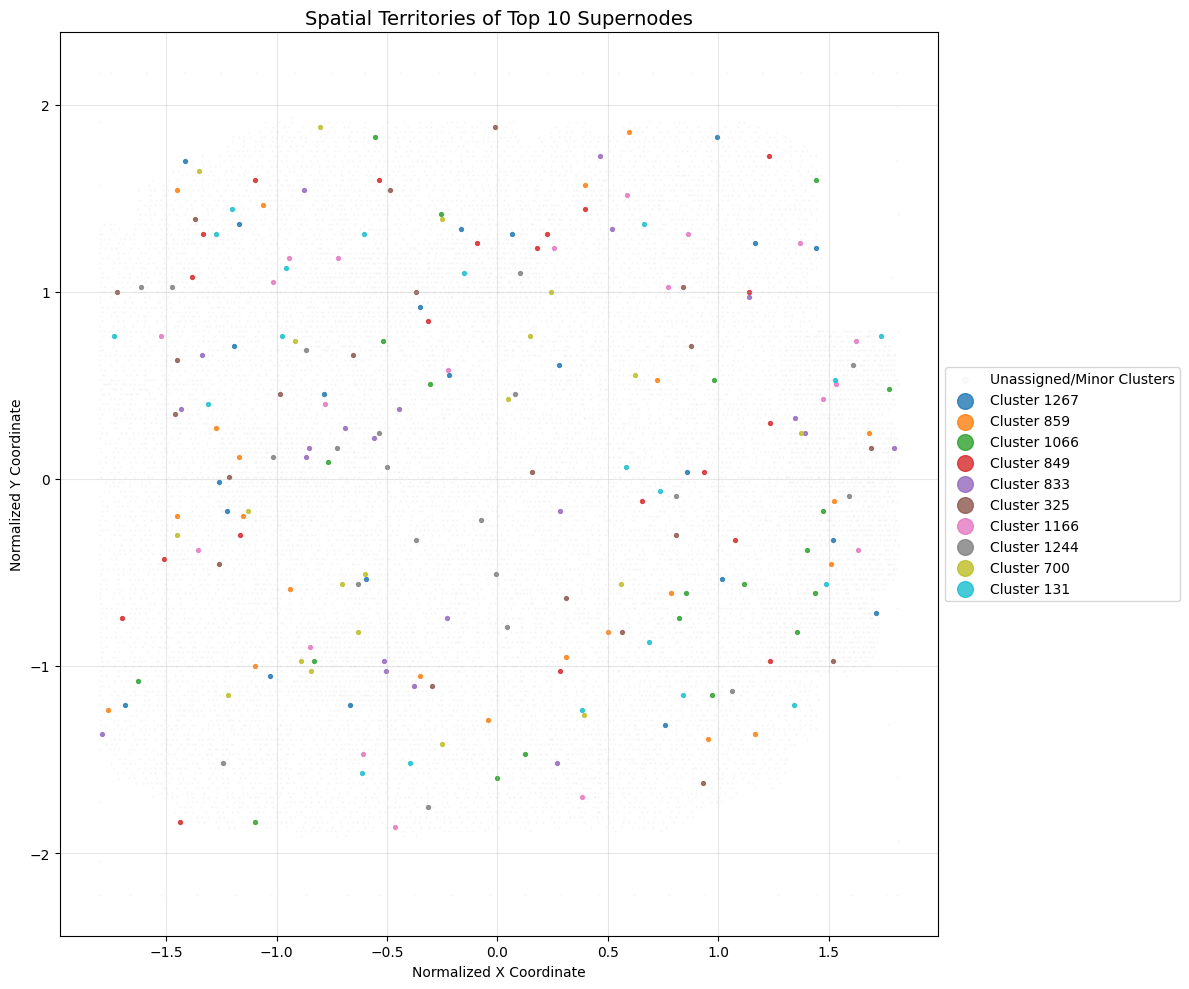

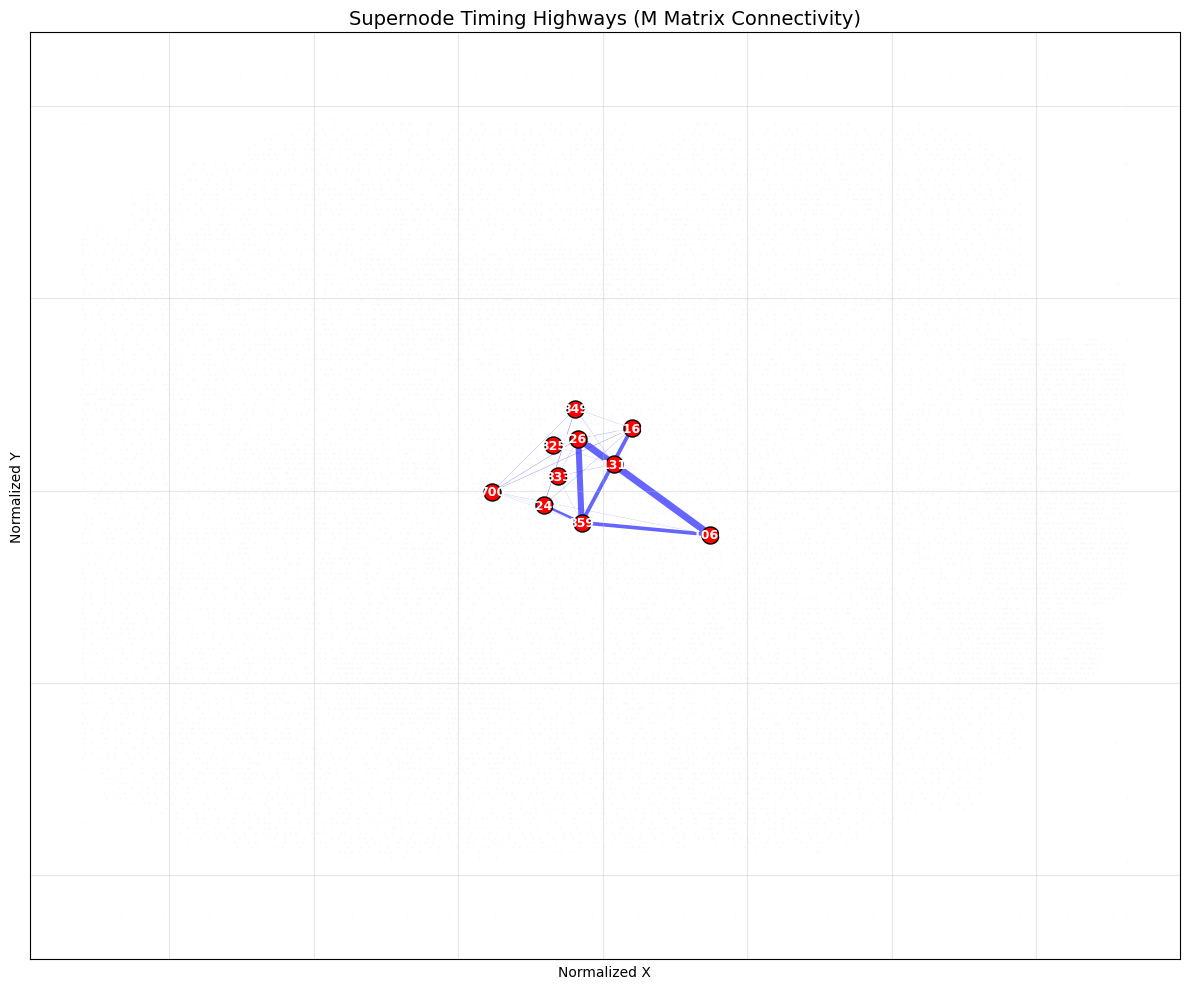

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import torch

# --- 0. RECALCULATE M (The Missing Step) ---
# We use the final 'C' from your training loop and your 'A_skip_csr'
with torch.no_grad():
    A_skip_gpu = A_skip_csr.to(C.device) 
    M_tensor = torch.matmul(C.t(), torch.sparse.mm(A_skip_gpu, C))
    M_dense = M_tensor.cpu().numpy()


# --- 1. Extract Data from Tensors ---
# Get the "hard" cluster assignment for each node by finding the max probability
C_probs = C.detach().cpu().numpy()
hard_assignments = np.argmax(C_probs, axis=1)

# Extract X and Y coordinates (columns 0 and 1 in your X_float)
x_coords = X_float[:, 0].cpu().numpy()
y_coords = X_float[:, 1].cpu().numpy()

# --- 2. Identify the Top Clusters ---
# Count how many nodes belong to each cluster
unique_clusters, counts = np.unique(hard_assignments, return_counts=True)

# Sort to find the indices of the largest clusters
top_cluster_indices = np.argsort(-counts)[:10]
top_clusters = unique_clusters[top_cluster_indices]

print(f"Visualizing Top 10 Clusters: {top_clusters}")
print(f"Sizes of Top 10 Clusters: {counts[top_cluster_indices]}")

# =========================================================
# PLOT 1: SPATIAL TERRITORIES (The Physical Layout)
# =========================================================
plt.figure(figsize=(12, 10))

# 1. Plot all gates as faint gray background noise
plt.scatter(x_coords, y_coords, s=1, c='lightgray', alpha=0.1, label='Unassigned/Minor Clusters')

# 2. Plot the top 10 clusters in distinct colors
cmap = plt.get_cmap('tab10')
for i, cluster_id in enumerate(top_clusters):
    # Create a boolean mask for nodes in this specific cluster
    mask = (hard_assignments == cluster_id)
    plt.scatter(x_coords[mask], y_coords[mask], s=8, color=cmap(i), alpha=0.8, label=f'Cluster {cluster_id}')

plt.title("Spatial Territories of Top 10 Supernodes", fontsize=14)
plt.xlabel("Normalized X Coordinate")
plt.ylabel("Normalized Y Coordinate")
# Increase marker size in legend so it's readable
plt.legend(markerscale=4, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# PLOT 2: SUPERNODE CONNECTIVITY (The Timing Highways)
# =========================================================
plt.figure(figsize=(12, 10))

# Plot the faint background map again for spatial context
plt.scatter(x_coords, y_coords, s=1, c='lightgray', alpha=0.05)

# Build a NetworkX graph to draw the connections
G = nx.Graph()
pos = {} # Dictionary to store the (x,y) center of each supernode

# 1. Calculate the spatial centroid of each top cluster
for cluster_id in top_clusters:
    mask = (hard_assignments == cluster_id)
    # The centroid is the average X and Y of all gates in the cluster
    centroid_x = np.mean(x_coords[mask])
    centroid_y = np.mean(y_coords[mask])
    
    pos[cluster_id] = (centroid_x, centroid_y)
    G.add_node(cluster_id)

# 2. Add edges based on the M matrix (Timing Connections)
# We calculate a threshold so we only draw the most important "highways"
sub_M = M_dense[np.ix_(top_clusters, top_clusters)]
# If all values are 0 (no timing connections between top 10), avoid threshold error
if sub_M.max() > 0:
    threshold = np.percentile(sub_M[sub_M > 0], 50) # Only keep top 50% of connections
    
    for i in top_clusters:
        for j in top_clusters:
            if i < j: # Prevent drawing duplicate undirected edges
                weight = M_dense[i, j]
                if weight > threshold:
                    G.add_edge(i, j, weight=weight)

# 3. Draw the Graph
edges = G.edges(data=True)
if len(edges) > 0:
    # Scale the line thickness based on how strong the M matrix connection is
    max_weight = max([d['weight'] for u, v, d in edges])
    edge_widths = [(d['weight'] / max_weight) * 5 for u, v, d in edges] 

    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='blue', alpha=0.6)

nx.draw_networkx_nodes(G, pos, node_color='red', node_size=150, edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=9, font_color='white', font_weight='bold')

plt.title("Supernode Timing Highways (M Matrix Connectivity)", fontsize=14)
plt.xlabel("Normalized X")
plt.ylabel("Normalized Y")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# C[1] is the row for node 1 (size [num_clusters])
max_index = torch.argmax(C[1])
print(C[2].max())
print(max_index)

max_index2 = torch.argmax(C[2])
print(max_index2)

tensor(0.7695, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(581, device='cuda:0')
tensor(115, device='cuda:0')
